In [2]:
from google.colab import files
uploaded = files.upload()   # choose train.gz from your computer

Saving kaggle.json to kaggle.json


In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!pip install -q kaggle
!kaggle competitions download -c avazu-ctr-prediction -f train.gz

100% 1.04G/1.04G [01:06<00:00, 16.8MB/s]



In [4]:
!ls -lh

total 1.1G
-rw-r--r-- 1 root root   67 Aug 17 09:25 kaggle.json
drwxr-xr-x 1 root root 4.0K Aug 10 13:31 sample_data
-rw-r--r-- 1 root root 1.1G Dec 11  2019 train.gz


In [5]:
import pandas as pd

# Load only the first 300,000 rows (out of ~40 million)
df = pd.read_csv('train.gz', compression='gzip', nrows=300000)

print("Shape:", df.shape)
df.head()

Shape: (300000, 24)


,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,...,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21
0,1.000009e+18,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1,2,15706,320,50,1722,0,35,-1,79
1,1.000017e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1,0,15704,320,50,1722,0,35,100084,79
2,1.000037e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1,0,15704,320,50,1722,0,35,100084,79
3,1.000064e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1,0,15706,320,50,1722,0,35,100084,79
4,1.000068e+19,0,14102100,1005,1,fe8cc448,9166c161,0569f928,ecad2386,7801e8d9,...,1,0,18993,320,50,2161,0,35,-1,157


In [6]:
# Column info and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 24 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                300000 non-null  float64
 1   click             300000 non-null  int64  
 2   hour              300000 non-null  int64  
 3   C1                300000 non-null  int64  
 4   banner_pos        300000 non-null  int64  
 5   site_id           300000 non-null  object 
 6   site_domain       300000 non-null  object 
 7   site_category     300000 non-null  object 
 8   app_id            300000 non-null  object 
 9   app_domain        300000 non-null  object 
 10  app_category      300000 non-null  object 
 11  device_id         300000 non-null  object 
 12  device_ip         300000 non-null  object 
 13  device_model      300000 non-null  object 
 14  device_type       300000 non-null  int64  
 15  device_conn_type  300000 non-null  int64  
 16  C14               30

In [7]:
# Check the target variable balance (click = 0 or 1)
df['click'].value_counts(normalize=True)

,proportion
click,
0,0.829297
1,0.170703


In [8]:
# Check for missing values
df.isnull().sum()

,0
id,0
click,0
hour,0
C1,0
banner_pos,0
site_id,0
site_domain,0
site_category,0
app_id,0
app_domain,0


In [9]:
# Create user_id (proxy for a unique user) and ad_id (proxy for a unique ad)
df['user_id'] = df['device_id'].astype(str) + "_" + df['device_ip'].astype(str)
df['ad_id'] = df['site_id'].astype(str) + "_" + df['app_id'].astype(str) + "_" + df['banner_pos'].astype(str)

print(df['user_id'].nunique(), "unique users")
print(df['ad_id'].nunique(), "unique ads")

116617 unique users
2728 unique ads


In [10]:
df['hour_str'] = df['hour'].astype(str)
df['day'] = df['hour_str'].str[4:6].astype(int)
df['hour_of_day'] = df['hour_str'].str[6:8].astype(int)
df.drop(columns=['hour', 'hour_str'], inplace=True)

In [11]:
df.drop(columns=['id'], inplace=True)

In [12]:
from sklearn.preprocessing import LabelEncoder
import joblib

categorical_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", categorical_cols)

encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

joblib.dump(encoders, 'encoders.pkl')  # save for later use in the Streamlit app

Categorical columns: ['site_id', 'site_domain', 'site_category', 'app_id', 'app_domain', 'app_category', 'device_id', 'device_ip', 'device_model', 'user_id', 'ad_id']


['encoders.pkl']

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['click'])
y = df['click']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, 'scaler.pkl')  # save for later use

print(X_train_scaled.shape, X_test_scaled.shape)

(240000, 25) (60000, 25)


In [14]:
import tensorflow as tf
from tensorflow.keras import layers, regularizers, models

n_features = X_train_scaled.shape[1]

model = models.Sequential([
    layers.Input(shape=(n_features,)),

    layers.Dense(128, kernel_regularizer=regularizers.l2(1e-4)),
    layers.ReLU(),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    layers.Dense(64, kernel_regularizer=regularizers.l2(1e-4)),
    layers.ReLU(),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(32, kernel_regularizer=regularizers.l2(1e-4)),
    layers.ReLU(),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,593 (57.00 KB)

 Trainable params: 14,145 (55.25 KB)

 Non-trainable params: 448 (1.75 KB)

In [15]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))
print(class_weight_dict)

{0: np.float64(0.6029211529862182), 1: np.float64(2.9290439112499693)}


In [16]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6
)

In [17]:
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=50,
    batch_size=512,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - accuracy: 0.5757 - auc: 0.6368 - loss: 0.7018 - val_accuracy: 0.5603 - val_auc: 0.6945 - val_loss: 0.6468 - learning_rate: 0.0010
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5685 - auc: 0.6766 - loss: 0.6583 - val_accuracy: 0.5512 - val_auc: 0.7023 - val_loss: 0.6442 - learning_rate: 0.0010
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5674 - auc: 0.6873 - loss: 0.6492 - val_accuracy: 0.5606 - val_auc: 0.7085 - val_loss: 0.6403 - learning_rate: 0.0010
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5691 - auc: 0.6944 - loss: 0.6433 - val_accuracy: 0.5702 - val_auc: 0.7106 - val_loss: 0.6362 - learning_rate: 0.0010
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5720 - auc: 0.6989 - loss: 0.6389 - val_accuracy: 0.5679 - val_auc: 0.7134 - val_loss: 0.6306 - learning_rate: 0.0010
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5745 - auc: 

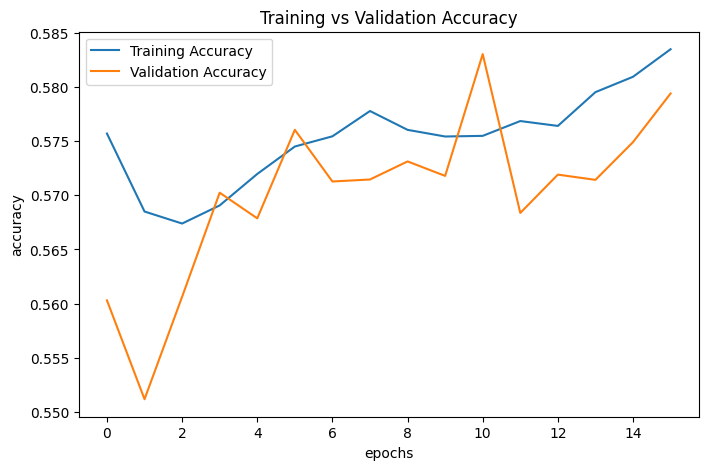

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.savefig('accuracy_plot.png', dpi=150, bbox_inches='tight')
plt.show()

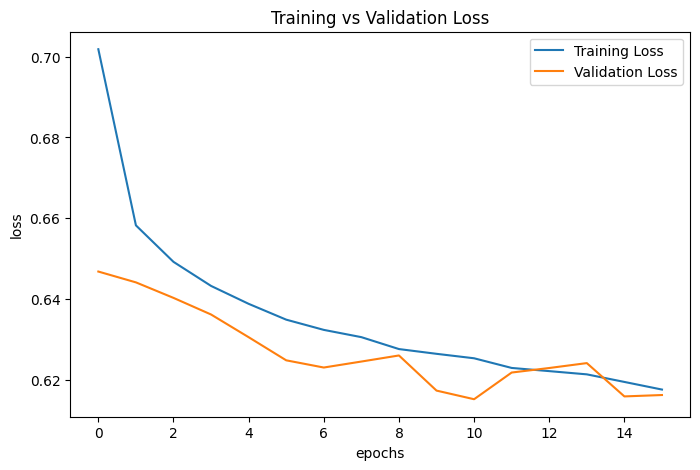

In [19]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.savefig('loss_plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
print(history.history['auc'][-1], history.history['val_auc'][-1])

0.7190062999725342 0.7267736196517944


In [21]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred_proba = model.predict(X_test_scaled).ravel()
y_pred = (y_pred_proba >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step
ROC-AUC: 0.7210547350288461

Confusion Matrix:
 [[26995 22763]
 [ 2256  7986]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.54      0.68     49758
           1       0.26      0.78      0.39     10242

    accuracy                           0.58     60000
   macro avg       0.59      0.66      0.54     60000
weighted avg       0.81      0.58      0.63     60000



In [23]:
import shap
import numpy as np

# Much smaller background + fewer samples to explain
background = shap.sample(X_train_scaled, 50)   # was 200 -> 50
explain_sample = X_test_scaled[np.random.choice(X_test_scaled.shape[0], 50, replace=False)]  # was 300 -> 50

explainer = shap.KernelExplainer(model.predict, background)
shap_values = explainer.shap_values(explain_sample)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 691ms/step


  0%|          | 0/50 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
3275/3275 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
3275/3275 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
3275/3275 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
3275/3275 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
3275/3275 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
3275/3275 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
3275/3275 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
3275/3275 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
3275/3275 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
3275/3275 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
3275/3275 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
3275/3275 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s

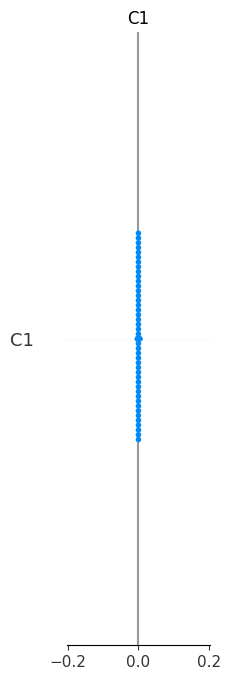

In [24]:
shap.summary_plot(
    shap_values, explain_sample,
    feature_names=X.columns.tolist(),
    show=False
)
import matplotlib.pyplot as plt
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
import numpy as np

print("shap_values shape:", np.array(shap_values).shape)  # sanity check first

shap_values shape: (50, 25, 1)


In [26]:
shap_values_fixed = np.array(shap_values)

# If shape is (50, 24, 1), squeeze the last dim
if shap_values_fixed.ndim == 3:
    shap_values_fixed = shap_values_fixed.squeeze(-1)

print("Fixed shape:", shap_values_fixed.shape)  # should now be (50, 24)

Fixed shape: (50, 25)


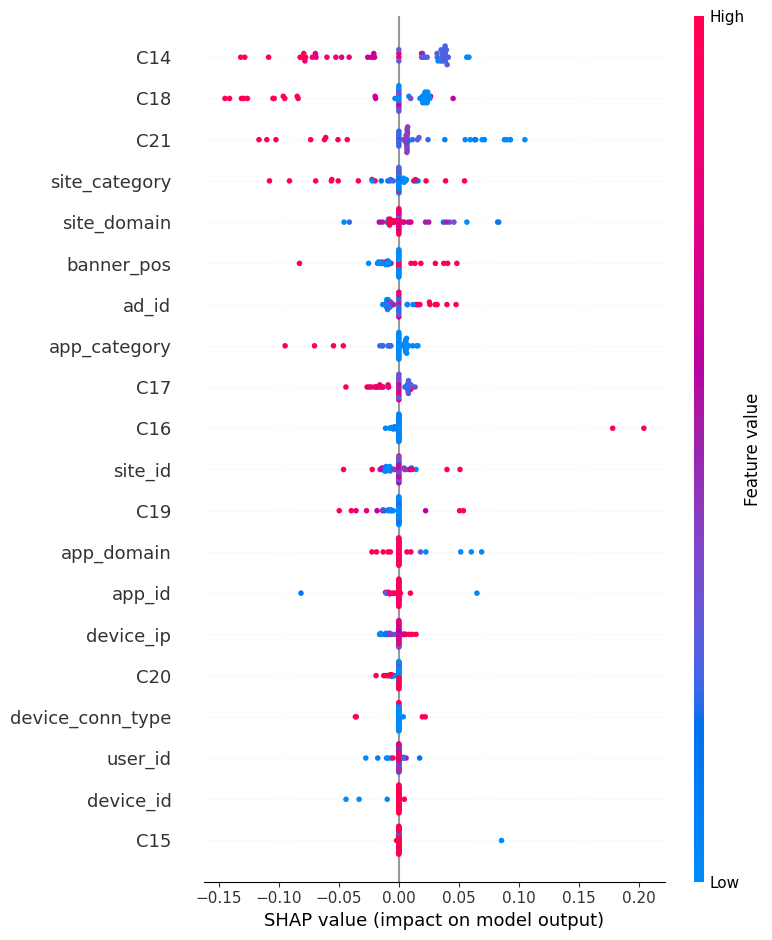

In [27]:
import matplotlib.pyplot as plt

shap.summary_plot(
    shap_values_fixed, explain_sample,
    feature_names=X.columns.tolist(),
    show=False
)
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
import numpy as np
import pandas as pd

# Attach predictions back to the test set for simulation
test_df = X_test.copy()
test_df['actual_click'] = y_test.values
test_df['predicted_ctr'] = y_pred_proba

# --- Group A: Random ad selection (baseline) ---
np.random.seed(42)
group_a = test_df.sample(frac=0.5, random_state=42)

# --- Group B: Model-driven — for each user, pick their highest predicted_ctr ad ---
group_b_pool = test_df.drop(group_a.index)
group_b = (
    group_b_pool.sort_values('predicted_ctr', ascending=False)
    .groupby('user_id', as_index=False)
    .head(1)   # top-1 recommended ad per user
)

print("Group A (random) size:", len(group_a))
print("Group B (model-recommended) size:", len(group_b))

Group A (random) size: 30000
Group B (model-recommended) size: 21130


In [31]:
ctr_a = group_a['actual_click'].mean()
ctr_b = group_b['actual_click'].mean()

print(f"Group A (Random) CTR: {ctr_a:.4f}")
print(f"Group B (Model)  CTR: {ctr_b:.4f}")
print(f"Lift: {(ctr_b - ctr_a) / ctr_a * 100:.2f}%")

Group A (Random) CTR: 0.1731
Group B (Model)  CTR: 0.1772
Lift: 2.34%


In [32]:
import joblib

# Save the trained Keras model
model.save('ctr_model.keras')

# Encoders and scaler were already saved in Step 4, but let's confirm/resave to be safe
joblib.dump(encoders, 'encoders.pkl')
joblib.dump(scaler, 'scaler.pkl')

# Also save the exact column order used for training — critical for the app to match input shape
joblib.dump(X.columns.tolist(), 'feature_columns.pkl')

print("Saved: ctr_model.keras, encoders.pkl, scaler.pkl, feature_columns.pkl")

Saved: ctr_model.keras, encoders.pkl, scaler.pkl, feature_columns.pkl


In [33]:
from google.colab import files
files.download('ctr_model.keras')
files.download('encoders.pkl')
files.download('scaler.pkl')
files.download('feature_columns.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
sample_for_app = test_df.drop(columns=['actual_click', 'predicted_ctr']).sample(20, random_state=1)
sample_for_app.to_csv('user_sample.csv', index=False)
files.download('user_sample.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>